# Feature Engineering

The raw dataset contains over 1.6 million time samples. Machine learning algorithms require one observation per diagnostic cycle. We therefore summarise each discharge curve using physically interpretable descriptors.

In [1]:
from pathlib import Path
import sys
import os
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
project_root_abs = os.path.abspath(PROJECT_ROOT)
sys.path.insert(0, project_root_abs)
from src.loader import load_oxford_dataset, extract_advanced_features
from scipy.signal import savgol_filter, find_peaks
import numpy as np

USE_DEFAULTS = True # True = runs presets silently | False = uses custom options below

In [2]:
df = load_oxford_dataset("C1dc")
display(df)

Reading cached Parquet dataset:
/Users/stephencurran/steviecurran.github.io/battery-degradation-prediction/github/data/Oxford_Battery_Dataset_Test=C1dc.parquet


,Cell,Cycle,Test,Time_min,Voltage_V,Charge_mAh,Temperature_C
0,1,0,C1dc,0.000000,4.191235,0.000000,40.026463
1,1,0,C1dc,0.016667,4.175756,-0.194831,40.051395
2,1,0,C1dc,0.033333,4.174312,-0.399788,39.988987
3,1,0,C1dc,0.050000,4.172628,-0.604746,39.976521
4,1,0,C1dc,0.066667,4.171545,-0.809702,39.964054
...,...,...,...,...,...,...,...
1610373,8,8100,C1dc,45.283278,2.750167,-558.299455,41.591419
1610374,8,8100,C1dc,45.299945,2.735212,-558.504936,41.603924
1610375,8,8100,C1dc,45.316611,2.719576,-558.710416,41.529045
1610376,8,8100,C1dc,45.333278,2.703419,-558.915894,41.653828


## From Raw Signals to Features

Here we summarise each diagnostic cycle by extracting physically meaningful descriptors. For each cell and each cycle these are:

- Time in minutes:
    
    - *t_cyc*:     the duration of the cycle 
    
    - *t_mean*:    the mean cycle time
    
    - *t_median*:  the mean in cycle time 
    
    - *t_to_4.0_V*:  the time to discharge to 4.0 V
    
    - *t_to_3.8_V*:  to 3.8 V
    
    - *t_to_3.5_V*:  to 3.5 V, where the rate of decrease seems to steepen<p>
    
     
- Voltage in V:

    - *V_mean*:    the mean 
    
    - *V_std*:     the standard deviation, which quantifies the overall spread or variation of the voltage curve during the cycle.
    
    - *V_median*:  the median 
    
    - *V_min*:     the minimum 
    
    - *Initial_V_slope*: the initial rate of voltage drop with time. This captures Ohmic drop changes. As the internal resistance increases with age, the initial voltage drop or rise spikes instantly, making the initial gradient steeper.
    
    - *3.8-3.5_V_slope*: the rate of voltage drop over 3.8 to 3.5 V. This captures mass-transport and plateau degradation. As active cathode material vanishes, the battery rushes through this plateau faster, forcing the window gradient value to shift significantly.
    
    - *VTI*: the time integrated voltage over the cycle, $\int V dt$.
    
    - *V_at_300mah*: the specific voltage reading recorded exactly when the cell reaches a discharge state of 300 mAh. This tracks the shifting height of the discharge voltage plateau at a fixed capacity anchor point.<p>
    
- Charge in mAh
    
    - *q_mean*:    the mean
    
    - *q_median*:  the median   
    
    - *q_final*:   the final
    
    - *dq_dV_peak_height*: the maximum peak height of the differential capacity ($\frac{dq}{dV}$) curve. This directly quantifies phase transitions and the remaining volume of active material inside the cell electrodes.
    
    - *dq_dV_peak_voltage*: the specific voltage coordinate where the primary $\frac{dq}{dV}$ peak occurs, tracking shifting chemical equilibrium and thermodynamic alignment changes due to cell degradation.<p>
    
- Temperature in <sup>o</sup>C

    - *T_peak*:    the peak (maximum) 
    
    - *T_min*:     the minimum 
     
    - *T_mean*:    the mean 
      
    - *T_median*:  the median 
    
    - *dT*:       T_peak - T_min
    
    - *dT_by_dt*: the rate of change of temperature with time. As resistance grows over thousands of cycles, Joule heating issues increase, making the temperature slope steeper.<p>
 
- Knee Cycle & Lifespan
 
   - *Knee_Cycle*: the specific cycle index where degradation transitions from gradual, linear wear into accelerated, non-linear aging, representing the point of maximum curvature on the health trajectory.
   
   - *Total_Life_Cycles*: the total lifespan or maximum number of completed test cycles recorded for a specific cell before testing was stopped.
  
  - *Pct_Lifespan_Reached*: the percentage of the cell's total operating life completed at the current cycle.
  
  - *Is_Aged*: A boolean classification flag indicating whether the current cycle has crossed past the cell's calculated *Knee_Cycle* <p>
   
- Energy (in Wh)
 
    - cycle_energy_wh: the total electrical energy delivered or absorbed during the cycle, calculated by integrating the product of voltage and current over time,  $\int V \cdot I dt$.

In [3]:
print("Calculating standard metrics (.agg pass)...")
dfc = (df.groupby(["Cell", "Cycle"]).agg(Test=("Test", "first"),
        t_cyc=("Time_min", "max"),t_mean=("Time_min", "mean"),
        t_median=("Time_min", "median"),T_peak=("Temperature_C", "max"),
        T_min=("Temperature_C", "min"),T_mean=("Temperature_C", "mean"), 
        T_median=("Temperature_C", "median"),
        V_mean=("Voltage_V", "mean"),V_std=("Voltage_V", "std"),
        V_median=("Voltage_V", "median"),V_min=("Voltage_V", "min"),
        q_mean=("Charge_mAh", "mean"),q_median=("Charge_mAh", "median"),
        q_final=("Charge_mAh", "last")).reset_index())

dfc["dT"] = dfc["T_peak"] - dfc["T_min"]

print("Extracting physical time-series and derivative features (.apply pass)...")
advanced_features = df.groupby(["Cell", "Cycle"]).apply(extract_advanced_features).reset_index()

print("Merging feature spaces...")
dfc = dfc.merge(advanced_features, on=["Cell", "Cycle"], how="left")

# =====================================================================
# KNEE-POINT LIFESPAN ANALYSIS (CELL METADATA INTERPRETATION)
# =====================================================================
print("Computing global curve layout curvature changes...")
TARGET_METRIC = "Initial_V_slope"
cell_knee_metadata = {}

# FIXED: Completed the broken section 3 vector chord loop
for cell_id in sorted(dfc["Cell"].unique()):
    cell_data = dfc[dfc["Cell"] == cell_id].dropna(subset=[TARGET_METRIC])
    x = cell_data["Cycle"].values
    y = cell_data[TARGET_METRIC].abs().values

    if len(x) < 10:
        continue

    p_start = np.array([x[0], y[0]])
    p_end = np.array([x[-1], y[-1]])
    chord_vector = p_end - p_start
    chord_length = np.linalg.norm(chord_vector)

    if chord_length > 0:
        unit_chord = chord_vector / chord_length
        distances = []
        for i in range(len(x)):
            p_current = np.array([x[i], y[i]])
            perp_distance = np.linalg.norm(p_current - (p_start + np.dot(p_current - p_start, unit_chord) * unit_chord))
            distances.append(perp_distance)
            
        max_distance_idx = np.argmax(distances)
        knee_cycle = x[max_distance_idx]
        total_life = x[-1]
        pct_lifespan = (knee_cycle / total_life) * 100
        
        cell_knee_metadata[cell_id] = {
            'Knee_Cycle': knee_cycle,
            'Total_Life_Cycles': total_life,
            'Pct_Lifespan_Reached': round(pct_lifespan, 1)
        }

# Inject metadata vectors and conditional booleans into row indexes
dfc['Knee_Cycle'] = dfc['Cell'].map(lambda c: cell_knee_metadata.get(c, {}).get('Knee_Cycle', np.nan))
dfc['Total_Life_Cycles'] = dfc['Cell'].map(lambda c: cell_knee_metadata.get(c, {}).get('Total_Life_Cycles', np.nan))
dfc['Pct_Lifespan_Reached'] = dfc['Cell'].map(lambda c: cell_knee_metadata.get(c, {}).get('Pct_Lifespan_Reached', np.nan))
dfc['Is_Aged'] = dfc['Cycle'] >= dfc['Knee_Cycle']

# =====================================================================
# EXPORT SUMMARY DATASET TO DISK
# =====================================================================
test = dfc['Test'].iloc[-1]

summary_csv = "../data/Oxford_Battery_Summary_Features_Test=%s.csv" %(test)
os.makedirs(os.path.dirname(summary_csv), exist_ok=True)
dfc.to_csv(summary_csv, index=False)

print(f"\n✅ Pipeline Complete!\nSummary file written to: {summary_csv}")
display(dfc)

Calculating standard metrics (.agg pass)...
Extracting physical time-series and derivative features (.apply pass)...
Merging feature spaces...
Computing global curve layout curvature changes...

✅ Pipeline Complete!
Summary file written to: ../data/Oxford_Battery_Summary_Features_Test=C1dc.csv


,Cell,Cycle,Test,t_cyc,t_mean,t_median,T_peak,T_min,T_mean,T_median,...,3.8-3.5_V_slope,dq_dV_peak_height,dq_dV_peak_voltage,cycle_energy_wh,V_at_300mAh,VTI,Knee_Cycle,Total_Life_Cycles,Pct_Lifespan_Reached,Is_Aged
0,1,0,C1dc,60.105502,30.058330,30.058333,41.174809,39.901646,40.419340,40.288570,...,-0.010926,11065.528592,3.735722,0.748383,3.789899,224.514990,8100,8200,98.8,False
1,1,100,C1dc,59.392401,29.699962,29.699964,41.124866,39.801758,40.327115,40.176216,...,-0.011038,13432.371085,3.728624,0.739612,3.788576,221.883625,8100,8200,98.8,False
2,1,200,C1dc,59.035679,29.524954,29.524958,41.112400,39.814266,40.327298,40.176216,...,-0.011110,10269.484525,3.731431,0.735340,3.788014,220.601920,8100,8200,98.8,False
3,1,300,C1dc,58.801063,29.408329,29.408333,41.124866,39.789291,40.322045,40.163750,...,-0.011151,9146.166946,3.726161,0.732432,3.787517,219.729633,8100,8200,98.8,False
4,1,400,C1dc,58.431495,29.216630,29.216631,41.124866,39.789291,40.314726,40.163750,...,-0.011204,10371.649426,3.727966,0.728019,3.786875,218.405816,8100,8200,98.8,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,8,7700,C1dc,45.661496,22.833331,22.833333,41.778606,39.744568,40.598783,40.243729,...,-0.013700,2245.746679,3.675047,0.568753,3.729332,170.625910,3800,8100,46.9,True
515,8,7800,C1dc,45.633561,22.824966,22.824972,41.641361,39.757076,40.573827,40.231262,...,-0.013911,2249.826016,3.676009,0.568103,3.729853,170.430875,3800,8100,46.9,True
516,8,7900,C1dc,45.512098,22.758299,22.758301,41.716198,39.782009,40.623791,40.306141,...,-0.013952,2441.706378,3.679578,0.566558,3.729091,169.967493,3800,8100,46.9,True
517,8,8000,C1dc,45.273759,22.641663,22.641666,41.841015,39.757076,40.603003,40.256195,...,-0.013795,2442.636548,3.673925,0.563957,3.726726,169.187116,3800,8100,46.9,True


We summarise the key features in the four panel plot below, but for completeness, as above, give the option to plot each parameter against any other.

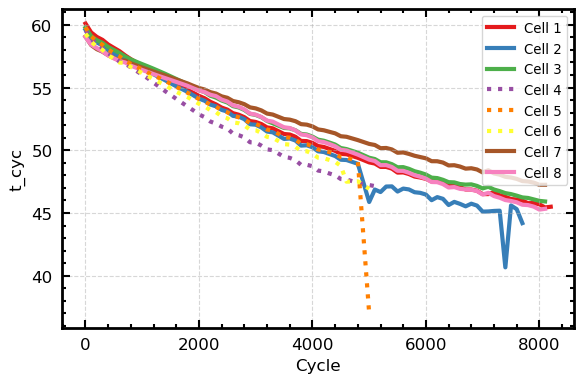

In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from src.plotter import summ_plot

if USE_DEFAULTS:
    cyc_no = 5000; xpara = 'Cycle';ypara = 't_cyc';save_fmt = 'no'  
else:
    paras = [col for col in dfc.columns  if col not in ['Cell',  'Test']] # if dfc is not None else ['Time_min', 'Voltage_V', 'Charge_mAh', 'Temperature_C']
    
    dd_xpara = widgets.Dropdown(options=paras, value='Cycle', 
                                description='X Param:', layout={'width': '35%'})
    dd_ypara = widgets.Dropdown(options=paras, value='t_cyc', 
                                description='Y Param:', layout={'width': '35%'})
    dd_format = widgets.Dropdown(options=['no','png','eps','pdf','svg'], 
                                 value='no', description='Save:', layout={'width': '20%'})

    menu = widgets.HBox([dd_xpara, dd_ypara, dd_format])
    ui = widgets.VBox([menu])

if USE_DEFAULTS:
    summ_plot(dfc,xpara, ypara, save_fmt)
else:
    clear_output(wait=True)
    out = widgets.interactive_output(summ_plot,{'dfc': widgets.fixed(dfc), 
            'xpara': dd_xpara, 'ypara': dd_ypara, 'save_fmt': dd_format}
    )
    display(ui,out)
    
    is_resetting = True
    dd_format.value = 'no'
    is_resetting = False

### Diagnostic plots

To summarise the cell perfomance, in the following plots we show the

- Operational perfomance
- Voltage degradation
- Thermodynamic behaviour
- Remaining discharge duration

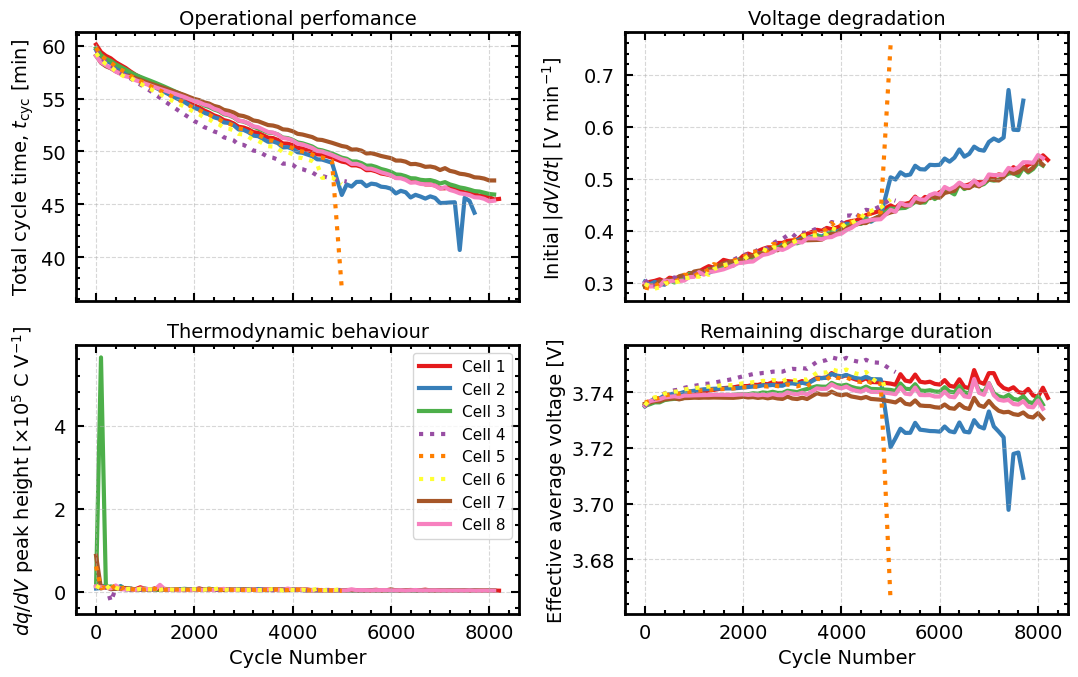

In [5]:
from src.plotter import four_plot
four_plot(dfc)

These show:

- **The Catastrophic Failure of Cell 5**

    Around cycle 4,900, Cell 5 (orange dotted line) undergoes sudden and catastrophic macroscopic failure across all monitored parameters. Its total cycle duration and effective average voltage drop off a cliff seamlessly, while its initial ohmic gradient spikes upward drastically. The observed behaviour is consistent with a rapid degradation event, although the underlying electrochemical mechanism cannot be determined from the present dataset alone.<p>
    
- **The Accelerated, Volatile Aging of Cell 2**
    
    Cell 2 (blue solid line) reaches its definitive structural degradation "knee point" at approximately cycle 4,900. Unlike the highly stable, progressive wear trajectories exhibited by its sister cohorts (Cells 1, 3, 7 and 8), Cell 2 transitions into a highly volatile state post-knee. The erratic, jagged oscillations in its total cycle time and effective average voltage strongly point to localized thermal fluctuations, unstable *solid electrolyte interphase* (SEI) fracturing/re-formation or irregular internal resistance transitions.<p>
    
- **Thermodynamic Chemical Health**
    
    The dramatic initial spike in differential capacity ($dq/dV$) peak height within the first 100 cycles, followed by an immediate, permanent flatline across all cohorts, captures two distinct early-life phenomena: the rapid stabilization of the SEI layer and an initial restructuring or *loss of active material* (LAM) within the electrode matrices. Beyond cycle 200, the electrochemical phase transformation kinetics remain uniform, shifting the tracking of degradation entirely onto transport and ohmic resistance mechanisms.<p>
    
- **Long-term Voltage Evolution**
    
    The effective average voltage across all cells exhibits a slight but noticeable upward trend for the first 4,000 cycles. This upward drift highlights an initial internal conditioning phase, likely driven by cathode microstructural wetting or progressive activation of local material sites. After crossing the 4,000-cycle threshold, this conditioning effect is completely overtaken by steady-state thermodynamic degradation, forcing a linear decline in voltage output. <p>
    
- **Lifespan Behavior of Cells 4 and 6**
    
    The remaining two short-duration cohorts—Cell 4 (purple dotted line) and Cell 6 (yellow dotted line)—show no early indicators of the acute degradation or failure mechanisms that destroyed Cell 5. Their trajectories remain perfectly parallel to the healthy solid-line baselines up until their termination near cycle 5,000, confirming that these specific trials were simply concluded early by design rather than stopped by cell failure.

### Cycle *$\approx4900$* Summary Table 

In [6]:
#Isolate the exact snapshot cross-section at cycle ~ 4,900
target_cycle = 4900
snapshot_df = dfc[dfc['Cycle'] == target_cycle].copy()

# Re-verify columns or fall back safely to empty placeholders if cells missed 4900
if snapshot_df.empty:
    # Fallback to the closest available cycle near 4,900 if exact index is missing
    closest_cycle = dfc.loc[(dfc['Cycle'] - target_cycle).abs().idxmin(), 'Cycle']
    print(f"ℹ️ Exact cycle 4,900 row missing. Evaluating closest baseline at cycle: {closest_cycle}")
    snapshot_df = dfc[dfc['Cycle'] == closest_cycle].copy()
    target_cycle = closest_cycle

# Clean up and format columns for the presentation matrix
summary_table = pd.DataFrame()
summary_table['Cell'] = snapshot_df['Cell']
summary_table['Test Type'] = snapshot_df['Test']
summary_table['Cycle Duration [min]'] = snapshot_df['t_cyc'].round(1)
summary_table['Ohmic Slope [V/min]'] = snapshot_df['Initial_V_slope'].abs().round(3)
summary_table['Peak dQ/dV [×10⁵]'] = (snapshot_df['dq_dV_peak_height'] / 1e5).round(2)
summary_table['Avg Voltage [V]'] = (snapshot_df['VTI'] / snapshot_df['t_cyc']).round(3)

# Generate an automated categorical Health Status classifier flag
def assign_health_status(row):
    # Cell 5 diagnostic signature checks
    if row['Ohmic Slope [V/min]'] > 0.65 or row['Cycle Duration [min]'] < 42.0:
        return "🚨 CATASTROPHIC FAILURE"
    # Cell 2 diagnostic signature checks
    elif row['Cell'] == 2:
        return "⚠️ POST-KNEE VOLATILE"
    # FIXED: Used standard parentheses tuple (4, 6) to avoid markdown parser bugs
    elif row['Cell'] in (4, 6):
        return "⏹️ FIXED TERMINATION"
    else:
        return "✅ PROGRESSIVE HEALTHY"

summary_table['Diagnostic Status'] = summary_table.apply(assign_health_status, axis=1)

summary_table = summary_table.sort_values('Cell').reset_index(drop=True)


print("-" * 80)
print(f"📊 Quantitative Cell Metrics Matrix Evaluated at Cycle {target_cycle}:")
print("-" * 80)
display(summary_table)

# Optional: Export this metadata table directly next to your summary files
matrix_csv = "../data/Oxford_Cell_Metrics_Snapshot_Cyc-cycle=%s_test=%s.csv" %(target_cycle,test)
os.makedirs(os.path.dirname(matrix_csv), exist_ok=True)
summary_table.to_csv(matrix_csv, index=False)
print(f"\n💾 Snapshot comparison matrix written to: {matrix_csv}")

ℹ️ Exact cycle 4,900 row missing. Evaluating closest baseline at cycle: 4800
--------------------------------------------------------------------------------
📊 Quantitative Cell Metrics Matrix Evaluated at Cycle 4800:
--------------------------------------------------------------------------------


,Cell,Test Type,Cycle Duration [min],Ohmic Slope [V/min],Peak dQ/dV [×10⁵],Avg Voltage [V],Diagnostic Status
0,1,C1dc,49.4,0.439,0.03,3.743,✅ PROGRESSIVE HEALTHY
1,2,C1dc,48.9,0.429,0.03,3.745,⚠️ POST-KNEE VOLATILE
2,3,C1dc,49.8,0.430,0.03,3.741,✅ PROGRESSIVE HEALTHY
3,4,C1dc,47.4,0.448,0.04,3.751,⏹️ FIXED TERMINATION
4,5,C1dc,49.1,0.436,0.03,3.743,✅ PROGRESSIVE HEALTHY
5,6,C1dc,47.5,0.445,0.04,3.743,⏹️ FIXED TERMINATION
6,7,C1dc,50.8,0.429,0.04,3.737,✅ PROGRESSIVE HEALTHY
7,8,C1dc,49.7,0.422,0.03,3.740,✅ PROGRESSIVE HEALTHY



💾 Snapshot comparison matrix written to: ../data/Oxford_Cell_Metrics_Snapshot_Cyc-cycle=4800_test=C1dc.csv


### Electrochemical Fingerprint Evolution

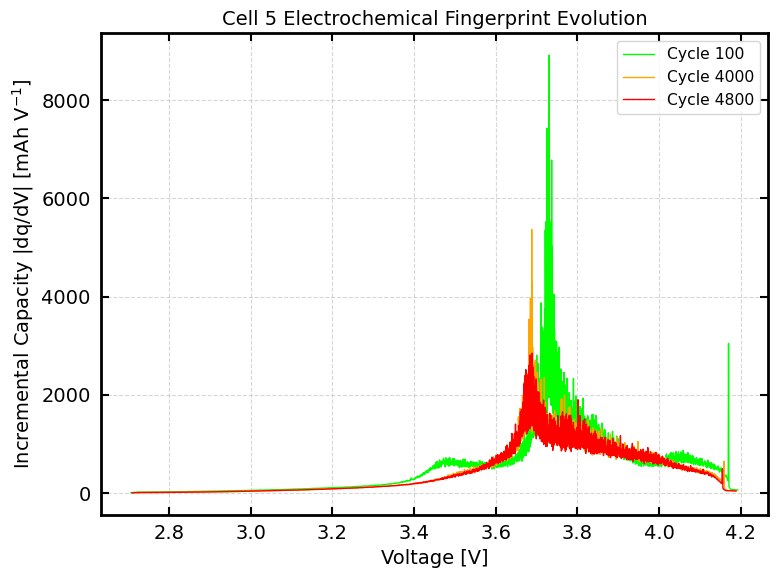

In [7]:
from src.plotter import peak_plot

if USE_DEFAULTS:
    cell = 5; save_fmt = 'no'  
else:
    cells = [x for x in range(1,dfc.Cell.nunique() + 1)] 

    dd_cell = widgets.Dropdown(options=cells, value=5, 
                                description='Cell no:', layout={'width': '25%'})
    
    dd_format = widgets.Dropdown(options=['no','png','eps','pdf','svg'], 
                                 value='no', description='Save:', 
                                 layout={'width': '20%'})

    menu = widgets.HBox([dd_cell, dd_format])
    ui = widgets.VBox([menu])
    
if USE_DEFAULTS:
    peak_plot(df,cell,save_fmt)
else:
    clear_output(wait=True)
    out = widgets.interactive_output(peak_plot, 
        {'df': widgets.fixed(df), 'cell': dd_cell, 'save_fmt': dd_format}
    )
    display(ui, out)
    is_resetting = True
    dd_format.value = 'no'
    is_resetting = False

Interestingly, differential capacity ($dq/dV$) profiling reveals that Cell 5's internal phase-transformation chemistry remains virtually unchanged between Cycle 4000 and Cycle 4800. 

The near-perfect overlap of these continuous curves indicates that chemical degradation had completely stabilized. The near overlap of the differential capacity curves suggests that little electrochemical evolution occurred between Cycles 4000 and 4800. 

If confirmed, this may indicate that the subsequent failure was dominated by a non-gradual degradation mechanism rather than continued electrochemical ageing.